In [ ]:
import pandas as pd
sales_data = pd.read_csv("data/07data.csv", encoding="shift_jis")

In [5]:
display(sales_data)

,no,最高気温,陳列方法,価格,競合価格,売上個数,来店客数
0,1,27.8,B,160,168,82,579
1,2,27.8,A,160,168,57,602
2,3,28.4,A,175,180,46,501
3,4,27.8,A,175,180,40,434
4,5,28.5,B,140,180,75,379
...,...,...,...,...,...,...,...
56,57,33.5,A,160,168,65,590
57,58,34.0,A,160,168,49,621
58,59,33.4,A,175,180,29,468
59,60,35.4,A,175,180,32,338


In [6]:
sales_data.describe()

,no,最高気温,価格,競合価格,売上個数,来店客数
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,31.000000,30.821311,160.819672,172.606557,62.524590,493.868852
std,17.752934,2.627934,14.496561,10.085102,25.796386,111.893175
min,1.000000,27.200000,140.000000,145.000000,14.000000,298.000000
25%,16.000000,28.400000,140.000000,168.000000,42.000000,411.000000
50%,31.000000,30.500000,160.000000,180.000000,62.000000,480.000000
75%,46.000000,33.300000,175.000000,180.000000,77.000000,590.000000
max,61.000000,36.500000,175.000000,180.000000,121.000000,711.000000


In [ ]:
# 一人あたりの個数を計算
sales_data["一人当たり"] = sales_data["売上個数"] / sales_data["来店客数"]
# 百人あたりの個数を追加
sales_data["百人あたり個数"] = sales_data["一人当たり"] * 100

In [9]:
display(sales_data)

,no,最高気温,陳列方法,価格,競合価格,売上個数,来店客数,一人当たり,百人あたり個数
0,1,27.8,B,160,168,82,579,0.141623,14.162349
1,2,27.8,A,160,168,57,602,0.094684,9.468439
2,3,28.4,A,175,180,46,501,0.091816,9.181637
3,4,27.8,A,175,180,40,434,0.092166,9.216590
4,5,28.5,B,140,180,75,379,0.197889,19.788918
...,...,...,...,...,...,...,...,...,...
56,57,33.5,A,160,168,65,590,0.110169,11.016949
57,58,34.0,A,160,168,49,621,0.078905,7.890499
58,59,33.4,A,175,180,29,468,0.061966,6.196581
59,60,35.4,A,175,180,32,338,0.094675,9.467456


In [ ]:
# 平均
sales_data["一人当たり"].mean()

0.1266584034716343

In [11]:
sales_data["百人あたり個数"].mean()

12.665840347163428

Text(0, 0.5, 'Per 100 customers')

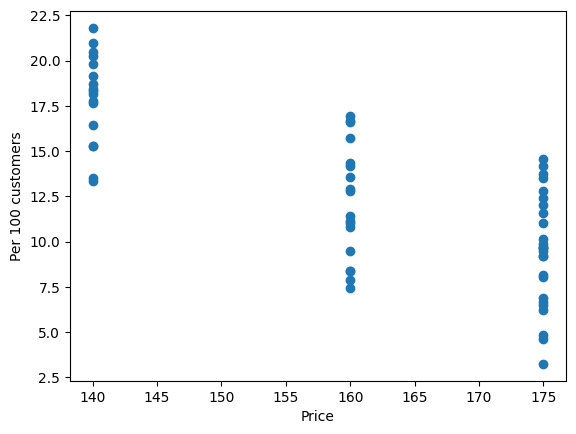

In [18]:
# 散布図を描画
import matplotlib.pyplot as plt
plt.scatter(sales_data["価格"], sales_data["百人あたり個数"])
plt.xlabel("Price")
plt.ylabel("Per 100 customers")

In [17]:
sales_data.describe()

,no,最高気温,価格,競合価格,売上個数,来店客数,一人当たり,百人あたり個数
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,31.000000,30.821311,160.819672,172.606557,62.524590,493.868852,0.126658,12.665840
std,17.752934,2.627934,14.496561,10.085102,25.796386,111.893175,0.045492,4.549154
min,1.000000,27.200000,140.000000,145.000000,14.000000,298.000000,0.032407,3.240741
25%,16.000000,28.400000,140.000000,168.000000,42.000000,411.000000,0.094675,9.467456
50%,31.000000,30.500000,160.000000,180.000000,62.000000,480.000000,0.127711,12.771084
75%,46.000000,33.300000,175.000000,180.000000,77.000000,590.000000,0.164474,16.447368
max,61.000000,36.500000,175.000000,180.000000,121.000000,711.000000,0.218018,21.801802


In [21]:
# 回帰分析
import statsmodels.api as sm
X = sales_data["価格"]
X = sm.add_constant(X)  # 定数項を追加
y = sales_data["百人あたり個数"]
model = sm.OLS(y, X).fit()  # OLS回帰モデルの適合
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                百人あたり個数   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     82.46
Date:                Sun, 25 May 2025   Prob (F-statistic):           8.38e-13
Time:                        18:33:55   Log-Likelihood:                -151.79
No. Observations:                  61   AIC:                             307.6
Df Residuals:                      59   BIC:                             311.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.1967      4.260     12.018      0.0

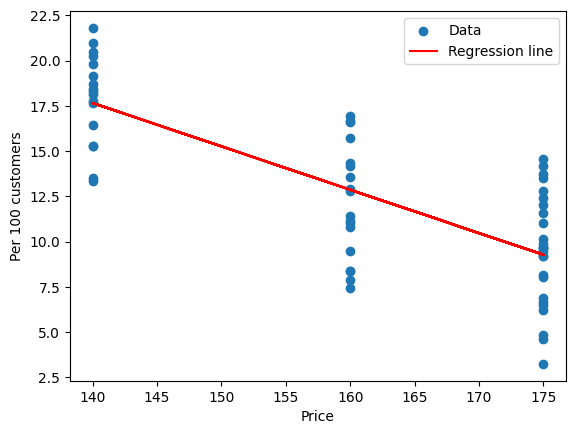

In [22]:
plt.scatter(sales_data["価格"], sales_data["百人あたり個数"], label="Data")

# 回帰直線
pred_y = model.predict(X)
plt.plot(sales_data["価格"], pred_y, color="red", label="Regression line")

# 軸ラベルと凡例
plt.xlabel("Price")
plt.ylabel("Per 100 customers")
plt.legend()


In [ ]:
import numpy as np
# 残差（実測値 - 予測値）
residuals = y - model.predict(X)
# RMSE の計算
rmse = np.sqrt(np.mean(residuals ** 2))
print("RMSE:", rmse)

RMSE: 2.9137488905224176


In [26]:
pd.set_option("display.max_rows", 1000) 
print(residuals / rmse)

0     0.446203
1    -1.164749
2    -0.029767
3    -0.017771
4     0.732694
5     0.036902
6     1.813692
7    -0.503049
8     1.305686
9    -1.604989
10    0.207835
11    0.173157
12   -0.414128
13    0.122985
14    0.009367
15   -0.705383
16   -0.887810
17   -0.416879
18    0.894280
19    1.423516
20    1.688297
21   -1.532879
22   -1.549727
23    0.608596
24   -2.068685
25    0.360089
26   -1.487415
27   -1.518921
28   -0.017244
29    0.978828
30   -0.944165
31    0.794012
32   -1.429657
33    0.517424
34    1.202133
35    1.397060
36    0.235491
37    1.077783
38    0.156951
39   -0.002394
40    0.962629
41    1.454737
42   -0.600983
43    1.281551
44   -0.379273
45    0.130674
46   -0.819750
47    1.145100
48   -0.825612
49   -1.872096
50    0.503026
51    0.951871
52    0.294539
53   -0.820549
54    0.234218
55    1.534823
56   -0.633300
57   -1.706299
58   -1.054240
59    0.068326
60    0.263242
dtype: float64


In [38]:
# ダミー変数化（Aを0, Bを1とする）
X = pd.get_dummies(sales_data["陳列方法"], drop_first=True)
X = sm.add_constant(X).astype(float)
# 目的変数
y = sales_data["売上個数"]
# 回帰
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   売上個数   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     18.16
Date:                Sun, 25 May 2025   Prob (F-statistic):           7.41e-05
Time:                        19:09:16   Log-Likelihood:                -276.13
No. Observations:                  61   AIC:                             556.3
Df Residuals:                      59   BIC:                             560.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.0909      3.960     12.902      0.0

In [40]:
# 回帰分析
import statsmodels.api as sm
X = sales_data["最高気温"]
X = sm.add_constant(X)  # 定数項を追加
y = sales_data["百人あたり個数"]
model = sm.OLS(y, X).fit()  # OLS回帰モデルの適合
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                百人あたり個数   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.5690
Date:                Sun, 25 May 2025   Prob (F-statistic):              0.454
Time:                        19:12:05   Log-Likelihood:                -178.17
No. Observations:                  61   AIC:                             360.3
Df Residuals:                      59   BIC:                             364.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.4511      6.938      1.074      0.2

In [31]:
X

,const,B
0,1.0,True
1,1.0,False
2,1.0,False
3,1.0,False
4,1.0,True
5,1.0,False
6,1.0,True
7,1.0,False
8,1.0,True
9,1.0,False
